# Predictive coding in the latent space (version 2)

Here's a different attempt at implementing a basic predictive coding example in the latent space using NEF-style representations.  This version will work with online learning to make direct connections between components.

In [71]:
import matplotlib.pyplot as plt
import nengo
import numpy as np

First, we need a clamp again

In [72]:
class Clamp(nengo.Network):
    def __init__(self, size_in, Kp=0.5, Kd=0.01, Ki=1):
        super().__init__()
        with self:
            self.target = nengo.Node(None, size_in=size_in)
            self.actual = nengo.Node(None, size_in=size_in)
            self.u = nengo.Node(None, size_in=size_in)

            self.d_target = nengo.Node(None, size_in=size_in)
            nengo.Connection(self.target, self.d_target, synapse=None, transform=1000)
            nengo.Connection(self.target, self.d_target, synapse=0, transform=-1000)
    
        
            self.q_diff = nengo.Node(None, size_in=size_in)
            nengo.Connection(self.target, self.q_diff, synapse=None)
            nengo.Connection(self.actual, self.q_diff, synapse=None, transform=-1)
    
            nengo.Connection(self.q_diff, self.u, transform=Kp, synapse=None)
    
    
            self.dq_diff = nengo.Node(None, size_in=size_in)
            nengo.Connection(self.d_target, self.dq_diff, synapse=None)
            #nengo.Connection(env.dq, dq_diff, synapse=None, transform=-1)
    
            nengo.Connection(self.dq_diff, self.u, transform=Kd, synapse=None)
    
            intq_diff = nengo.Node(lambda t,x: x[1:] if x[0]>0 else x[1:]*0, size_in=size_in+1)

            nengo.Connection(self.target, intq_diff[1:], synapse=None)
            nengo.Connection(self.actual, intq_diff[1:], synapse=None, transform=-1)
            nengo.Connection(intq_diff, intq_diff[1:], synapse=0.1)
            
            nengo.Connection(intq_diff, self.u, transform=Ki, synapse=None)            
            
            self.active=nengo.Node(None, size_in=1)
            self.output = nengo.Node(lambda t,x: x[1:] if x[0]>0 else x[1:]*0, size_in=size_in+1)
            nengo.Connection(self.active, self.output[0], synapse=None)
            nengo.Connection(self.active, intq_diff[0], synapse=None)
            nengo.Connection(self.u, self.output[1:], synapse=None)

Now we'll make direct connections between the two ensembles representing the two variables.  We'll then initialize connections between the ensembles and put learning rules on them.  

The question, of course, is what is the error signal for those learning rules?   Interestingly, it turns out we've already computed that!  The error is *exactly* the control signal from the PID controller!!!  

Let's try this with a simple XOR example.  We'll clamp x and y for the first 10 seconds, then we'll release the clamp on y and see what happens.  Notice that releasing the clamp also turns off the learning!

In [73]:
model = nengo.Network()
with model:
    x = nengo.Ensemble(n_neurons=1000, dimensions=2, radius=1.5)
    y = nengo.Ensemble(n_neurons=50, dimensions=1)

    clamp_x = Clamp(size_in=2)
    nengo.Connection(x, clamp_x.actual)
    nengo.Connection(clamp_x.output, x)

    clamp_y = Clamp(size_in=1)
    nengo.Connection(y, clamp_y.actual)
    nengo.Connection(clamp_y.output, y)

    alpha=1e-3
    c_x2y = nengo.Connection(x, y, function=lambda x: 0, learning_rule_type=nengo.PES(learning_rate=alpha))
    c_y2x = nengo.Connection(y, x, function=lambda x: [0,0], learning_rule_type=nengo.PES(learning_rate=alpha))

    nengo.Connection(clamp_y.output, c_x2y.learning_rule, synapse=None, transform=-1)
    nengo.Connection(clamp_x.output, c_y2x.learning_rule, synapse=None, transform=-1)
    
    stim_x = np.array([[1,1],[-1,-1],[-1,1],[1,-1]])
    stim_y = np.array([[1],[1],[-1],[-1]])
    present_x = nengo.Node(nengo.processes.PresentInput(stim_x, presentation_time=0.1))
    present_y = nengo.Node(nengo.processes.PresentInput(stim_y, presentation_time=0.1))
    nengo.Connection(present_x, clamp_x.target)
    nengo.Connection(present_y, clamp_y.target)
    
    clamp_y_active = nengo.Node(lambda t: 1 if t<10 else -1)
    clamp_x_active = nengo.Node(1)
    nengo.Connection(clamp_x_active, clamp_x.active)
    nengo.Connection(clamp_y_active, clamp_y.active)
    
    p_x = nengo.Probe(x, synapse=0.01)
    p_y = nengo.Probe(y, synapse=0.01)
    p_target_y = nengo.Probe(present_y)
sim = nengo.Simulator(model)
with sim:
    sim.run(11)


    




HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

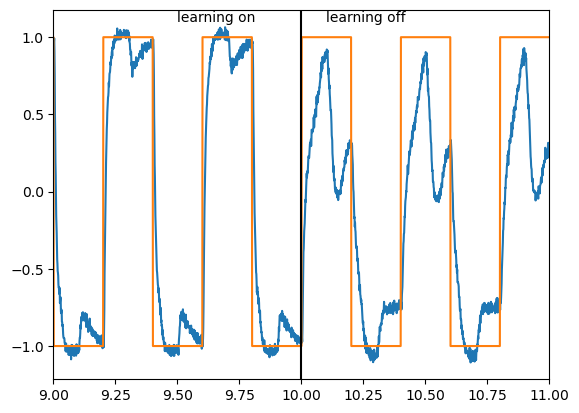

In [74]:
plt.plot(sim.trange(), sim.data[p_y])
plt.plot(sim.trange(), sim.data[p_target_y])
plt.axvline(10, c='k')
plt.xlim(9,11)
plt.text(9.5,1.1, "learning on")
plt.text(10.1,1.1, "learning off")
plt.show()

Let's try to improve things by switching x to an SSP representation

In [75]:
import sspspace
ssp_x = sspspace.RandomSSPSpace(domain_dim=2, ssp_dim=256)

model = nengo.Network()
with model:
    x = nengo.Ensemble(n_neurons=1000, dimensions=256, 
                       #intercepts=nengo.dists.CosineSimilarity(256+2),
                       intercepts=nengo.dists.Choice([0.05]),
                      )
    y = nengo.Ensemble(n_neurons=50, dimensions=1)

    clamp_x = Clamp(size_in=256)
    nengo.Connection(x, clamp_x.actual)
    nengo.Connection(clamp_x.output, x)

    clamp_y = Clamp(size_in=1)
    nengo.Connection(y, clamp_y.actual)
    nengo.Connection(clamp_y.output, y)

    alpha=3e-3
    c_x2y = nengo.Connection(x, y, function=lambda x: 0, learning_rule_type=nengo.PES(learning_rate=alpha))
    c_y2x = nengo.Connection(y, x, function=lambda x: [0]*256, learning_rule_type=nengo.PES(learning_rate=alpha))

    nengo.Connection(clamp_y.output, c_x2y.learning_rule, synapse=None, transform=-1)
    nengo.Connection(clamp_x.output, c_y2x.learning_rule, synapse=None, transform=-1)
    
    stim_x = np.array([[1,1],[-1,-1],[-1,1],[1,-1]])
    stim_y = np.array([[1],[1],[-1],[-1]])
    present_x = nengo.Node(nengo.processes.PresentInput(stim_x, presentation_time=0.1))
    present_y = nengo.Node(nengo.processes.PresentInput(stim_y, presentation_time=0.1))
    nengo.Connection(present_x, clamp_x.target, function=lambda x: ssp_x.encode(x).flat)
    nengo.Connection(present_y, clamp_y.target)
    
    clamp_y_active = nengo.Node(lambda t: 1 if t<10 else -1)
    clamp_x_active = nengo.Node(1)
    nengo.Connection(clamp_x_active, clamp_x.active)
    nengo.Connection(clamp_y_active, clamp_y.active)
    
    p_x = nengo.Probe(x, synapse=0.01)
    p_y = nengo.Probe(y, synapse=0.01)
    p_target_y = nengo.Probe(present_y)
sim = nengo.Simulator(model)
with sim:
    sim.run(11)


    




HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

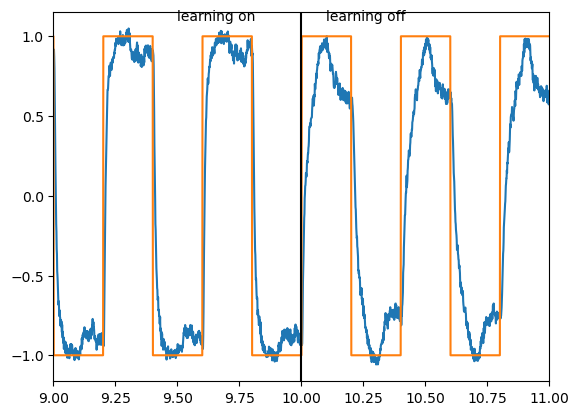

In [76]:
plt.plot(sim.trange(), sim.data[p_y])
plt.plot(sim.trange(), sim.data[p_target_y])
plt.axvline(10, c='k')
plt.xlim(9,11)
plt.text(9.5,1.1, "learning on")
plt.text(10.1,1.1, "learning off")
plt.show()